# H1 피처 선택 (재설계 2026-06): 접속 통제 + 재투자 축 탐색

**재설계 배경 (PLAN.md 0.1/0.3):**
- 표본을 **12개월 중 ≥10개월 접속**으로 통제 → 접속(access)은 **통제변인**이며 클러스터링 후보 피처풀에서 **전면 제외**.
- 접속 통제 결과 **누적 경험치(cumEXP) 성장률이 거의 균일**(전원 이벤트 baseline EXP 획득) → 판별력 상실 → 실루엣 최대화 탐색에서 자연 탈락.
- 주차 정의(0.1) = 성장 동결 + 보스 재화 **미재투자**. 판별축 = **재투자**: 유니온 성장(Δunion), 헥사 조각 소비(Δhfrag). heavy-tail → **log1p** 로 하위(near-zero) 구조 노출.

**탐색:** 완전탐색(2~5) + greedy. **성장 정체(=주차 후보) 클러스터 = 스케일 중심좌표 합 최저** 클러스터 (h1_clustering 동일). 외부 proxy `park`(stag≥4)는 enrich/recall 게이트용(선정기준 아님).

In [1]:
import os, warnings, time, json
warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager
_font_path = "../assets/NanumSquareNeo-bRg.ttf"
font_manager.fontManager.addfont(_font_path)
matplotlib.rcParams["font.family"] = font_manager.FontProperties(fname=_font_path).get_name()
matplotlib.rcParams["axes.unicode_minus"] = False
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42
UPPER_CLIP_Q = 0.99
CP_WINSOR_Q = (0.01, 0.99)

def qclip_nonnegative(s, upper_q=UPPER_CLIP_Q):
    s = pd.to_numeric(s, errors="coerce").clip(lower=0)
    return s.clip(upper=s.quantile(upper_q))

def winsor_quantile(s, lower_q=CP_WINSOR_Q[0], upper_q=CP_WINSOR_Q[1]):
    s = pd.to_numeric(s, errors="coerce")
    lo, hi = s.quantile([lower_q, upper_q])
    return s.clip(lo, hi)

def find_elbow_k(ks, inertias):
    x = np.array(ks, dtype=float); y = np.array(inertias, dtype=float)
    x = (x - x.min()) / (x.max() - x.min() + 1e-12)
    y = (y - y.min()) / (y.max() - y.min() + 1e-12)
    x0, y0, x1, y1 = x[0], y[0], x[-1], y[-1]
    num = np.abs((y1 - y0) * x - (x1 - x0) * y + x1 * y0 - y1 * x0)
    den = np.hypot(y1 - y0, x1 - x0) + 1e-12
    return ks[int(np.argmax(num / den))]

df_raw = pd.read_csv("../data/features_monthly.csv", encoding="utf-8-sig")
mc = pd.read_csv("../data/main_characters.csv", encoding="utf-8-sig", usecols=["ocid", "class_group"])
df = df_raw.merge(mc, on="ocid", how="left")
hf = pd.read_csv("../data/hexa_fragments.csv", encoding="utf-8-sig",
                 usecols=["ocid", "avg_monthly_delta_hexa_frag", "recent3_delta_hexa_frag", "recent6_delta_hexa_frag"])
df = df.merge(hf, on="ocid", how="left")

df = df[df["level"].between(270, 290)].copy()
df["level_bin"] = pd.cut(df["level"], bins=[269, 279, 285, 290], labels=["270-279", "280-285", "286-290"])
_core = ["avg_monthly_delta_level", "avg_monthly_delta_combat_power", "avg_monthly_delta_union_level"]
df = df.dropna(subset=_core).copy()
df["union_level"] = df["union_level"].fillna(0)
df["delta_cp_winsor"] = winsor_quantile(df["avg_monthly_delta_combat_power"])
df["delta_union"]     = qclip_nonnegative(df["avg_monthly_delta_union_level"])
df["delta_auth"]      = qclip_nonnegative(df["avg_monthly_delta_authentic_symbol"])
df["delta_level"]     = qclip_nonnegative(df["avg_monthly_delta_level"])
df["delta_hexa"]      = qclip_nonnegative(df["avg_monthly_delta_hexa"])
df["delta_hfrag"]     = qclip_nonnegative(df["avg_monthly_delta_hexa_frag"]).fillna(0)
df["log_delta_union"] = np.log1p(df["delta_union"])
df["log_delta_hfrag"] = np.log1p(df["delta_hfrag"])
df["log_delta_auth"]  = np.log1p(df["delta_auth"])
df["log_delta_hexa"]  = np.log1p(df["delta_hexa"])
# 전투력은 음수(감소=주차 신호) 24% → log1p 직접 불가 → signed-log 로 부호 보존+magnitude 압축
df["slog_delta_cp"]   = np.sign(df["delta_cp_winsor"]) * np.log1p(np.abs(df["delta_cp_winsor"]))
df_final = df.reset_index(drop=True)
_stag = ["delta_level", "delta_cp_winsor", "delta_union", "delta_auth"]
df_final["stagnation_score"] = sum((df_final[c] <= df_final[c].quantile(0.25)).astype(int) for c in _stag)
BAND_LABELS = ["270-279", "280-285", "286-290"]
print(f"df_final: {len(df_final):,}명  |  컬럼 {df_final.shape[1]}개")
print(f"접속 통제: access_active_months>=10 비율 = {(df_final['access_active_months']>=10).mean()*100:.1f}%")

df_final: 1,999명  |  컬럼 61개
접속 통제: access_active_months>=10 비율 = 100.0%


## 접속 통제 후 cumEXP 균일성 점검

≥10/12 통제 표본에서 cumEXP 성장률이 좁은 범위에 몰리면 군집 판별력이 없어 제외 대상.

In [2]:
ce = df_final["log1p_avg_monthly_delta_cumexp"].fillna(0)
print("cumEXP(log1p Δ) 분포:")
print(f"  median={ce.median():.2f}  IQR=[{ce.quantile(.25):.2f}, {ce.quantile(.75):.2f}]  p10={ce.quantile(.10):.2f}  p90={ce.quantile(.90):.2f}")
print(f"  변동계수(std/mean)={ce.std()/(ce.mean()+1e-9):.3f}  (작을수록 균일 → 판별력 낮음)")
print("\n재투자 축 0 비율 (낮을수록 연속분포):")
print(f"  Δunion==0: {(df_final['delta_union']==0).mean()*100:.1f}%  Δhfrag==0: {(df_final['delta_hfrag']==0).mean()*100:.1f}%  Δcp<0(감소): {(df_final['avg_monthly_delta_combat_power']<0).mean()*100:.1f}%")

cumEXP(log1p Δ) 분포:
  median=30.04  IQR=[28.84, 31.01]  p10=28.05  p90=31.46
  변동계수(std/mean)=0.078  (작을수록 균일 → 판별력 낮음)

재투자 축 0 비율 (낮을수록 연속분포):
  Δunion==0: 1.5%  Δhfrag==0: 7.2%  Δcp<0(감소): 24.4%


## 후보 피처 행렬 (접속 family 제외)

성장/재투자 축 raw + log. **접속(access) family 제외(통제변인).** near-constant(dom_frac>0.70) 자동 제거. 패밀리 = prefix; log·raw 동일 패밀리.

In [3]:
F = pd.DataFrame(index=df_final.index)
F["cumexp_avg"] = df_final["log1p_avg_monthly_delta_cumexp"].fillna(0)
F["cp_avg"]     = df_final["delta_cp_winsor"]
F["union_avg"]  = df_final["delta_union"]
F["union_log"]  = df_final["log_delta_union"]
F["hfrag_avg"]  = df_final["delta_hfrag"]
F["hfrag_log"]  = df_final["log_delta_hfrag"]
F["auth_avg"]   = df_final["delta_auth"]
F["auth_log"]   = df_final["log_delta_auth"]
F["hexa_avg"]   = df_final["delta_hexa"]
F["hexa_log"]   = df_final["log_delta_hexa"]
F["cp_slog"]    = df_final["slog_delta_cp"]
F["level_avg"]  = df_final["delta_level"]
assert F.isna().sum().sum() == 0

dom = {c: F[c].round(6).value_counts(normalize=True).iloc[0] for c in F.columns}
DROP_NC = [c for c, v in dom.items() if v > 0.70]
print("near-constant 제거(dom_frac>0.70):", {c: round(dom[c], 3) for c in DROP_NC})
F = F.drop(columns=DROP_NC)
FULL_POOL = list(F.columns)
print(f"후보 피처 풀 {len(FULL_POOL)}개: {FULL_POOL}")

park = (df_final["stagnation_score"] >= 4)
stag4 = (df_final["stagnation_score"] == 4)
parked_proxy = (df_final["delta_level"] <= 0.1)
print(f"\npark(stag>=4): {park.mean():.1%} (n={int(park.sum())})  |  parked_proxy(Δlv<=0.1): {parked_proxy.mean():.1%}")

FAMILY = {c: c.split("_")[0] for c in F.columns}
CORR = F.corr().abs()
def max_pair_corr(cols):
    cols = list(cols)
    if len(cols) < 2:
        return 0.0
    sub = CORR.loc[cols, cols].values
    return float(np.max(sub[np.triu_indices(len(cols), k=1)]))
print("패밀리:", sorted(set(FAMILY.values())))

near-constant 제거(dom_frac>0.70): {}
후보 피처 풀 12개: ['cumexp_avg', 'cp_avg', 'union_avg', 'union_log', 'hfrag_avg', 'hfrag_log', 'auth_avg', 'auth_log', 'hexa_avg', 'hexa_log', 'cp_slog', 'level_avg']

park(stag>=4): 5.4% (n=107)  |  parked_proxy(Δlv<=0.1): 11.8%
패밀리: ['auth', 'cp', 'cumexp', 'hexa', 'hfrag', 'level', 'union']


## 평가 함수

조합 → StandardScale → KMeans(k=2~6) 최고 실루엣. **성장 정체 = 스케일 중심좌표 합 최저**. `valid` = size∈[1%,50%] & enrich≥1.5 & recall≥0.5 & maxfrac≤0.90 & minfrac≥0.02.

In [4]:
SEARCH_KS = list(range(2, 7)); N_INIT_SRCH = 4; SIL_SAMPLE = 1200

def _best_km(Xs, ks, n_init, sample):
    best = (-1.0, None, None)
    for k in ks:
        lbl = KMeans(n_clusters=k, n_init=n_init, random_state=RANDOM_STATE).fit_predict(Xs)
        s = (silhouette_score(Xs, lbl, sample_size=sample, random_state=RANDOM_STATE)
             if sample and len(Xs) > sample else silhouette_score(Xs, lbl))
        if s > best[0]:
            best = (s, k, lbl)
    return best

def stagnant_label(Xs, lbl):
    cen = pd.DataFrame(Xs).groupby(lbl).mean()
    return cen.sum(axis=1).idxmin()

def eval_set(cols, ks=SEARCH_KS, n_init=N_INIT_SRCH, sample=SIL_SAMPLE):
    Xs = StandardScaler().fit_transform(F[list(cols)].values)
    sil, k, lbl = _best_km(Xs, ks, n_init, sample)
    fr = pd.Series(lbl).value_counts(normalize=True)
    max_frac, min_frac = float(fr.max()), float(fr.min())
    pc = stagnant_label(Xs, lbl)
    mask = (lbl == pc)
    size = mask.mean()
    enrich = park.values[mask].mean() / max(park.mean(), 1e-9)
    recall = park.values[mask].sum() / max(park.sum(), 1)
    valid = ((0.01 <= size <= 0.50) and (enrich >= 1.5) and (recall >= 0.5)
             and (max_frac <= 0.90) and (min_frac >= 0.02))
    return {"sil": round(float(sil), 4), "k": int(k), "n_feat": len(cols),
            "n_fam": len(set(FAMILY[c] for c in cols)), "maxcorr": round(max_pair_corr(cols), 2),
            "size%": round(size * 100, 1), "enrich": round(float(enrich), 2),
            "recall": round(float(recall), 3), "maxfrac": round(max_frac, 2), "valid": bool(valid)}

print("[union_log, hfrag_log]:", eval_set(["union_log", "hfrag_log"]))
print("[cp_avg, union_log, hfrag_log]:", eval_set(["cp_avg", "union_log", "hfrag_log"]))

[union_log, hfrag_log]: {'sil': 0.4504, 'k': 2, 'n_feat': 2, 'n_fam': 2, 'maxcorr': 0.25, 'size%': np.float64(25.7), 'enrich': 3.49, 'recall': 0.897, 'maxfrac': 0.74, 'valid': True}
[cp_avg, union_log, hfrag_log]: {'sil': 0.3512, 'k': 6, 'n_feat': 3, 'n_fam': 3, 'maxcorr': 0.39, 'size%': np.float64(9.9), 'enrich': 5.47, 'recall': 0.542, 'maxfrac': 0.43, 'valid': True}


## 완전탐색 — 큐레이션 풀 (크기 2~5)

In [5]:
_cur = ["cumexp_avg", "cp_slog", "union_log", "hfrag_log", "auth_log", "hexa_avg", "hexa_log", "level_avg"]
CURATED = [c for c in _cur if c in FULL_POOL]
print(f"큐레이션 풀 {len(CURATED)}개: {CURATED}")
rows, t0 = [], time.time()
for r in range(2, 6):
    for combo in combinations(CURATED, r):
        res = eval_set(combo); res["features"] = combo; rows.append(res)
exh = pd.DataFrame(rows)
print(f"평가 조합 {len(exh)}개  |  {time.time() - t0:.1f}s")
exh_valid = exh[exh["valid"]].sort_values("sil", ascending=False).reset_index(drop=True)
print(f"\nvalid 조합: {len(exh_valid)} / {len(exh)}")
for _, r in exh_valid.head(15).iterrows():
    print(f"  sil={r['sil']:.4f} k={r['k']} nf={r['n_feat']} fam={r['n_fam']} corr={r['maxcorr']:.2f} size={r['size%']:>4}% enrich={r['enrich']} recall={r['recall']:.2f}  {list(r['features'])}")

큐레이션 풀 8개: ['cumexp_avg', 'cp_slog', 'union_log', 'hfrag_log', 'auth_log', 'hexa_avg', 'hexa_log', 'level_avg']


평가 조합 210개  |  18.7s

valid 조합: 51 / 210
  sil=0.6932 k=3 nf=2 fam=2 corr=0.26 size=24.3% enrich=4.07 recall=0.99  ['cp_slog', 'level_avg']
  sil=0.6472 k=3 nf=2 fam=2 corr=0.23 size=23.7% enrich=4.18 recall=0.99  ['cp_slog', 'hexa_avg']
  sil=0.5833 k=2 nf=2 fam=2 corr=0.33 size=24.5% enrich=4.04 recall=0.99  ['cp_slog', 'auth_log']
  sil=0.5727 k=2 nf=2 fam=2 corr=0.28 size=24.5% enrich=4.04 recall=0.99  ['cp_slog', 'hexa_log']
  sil=0.5549 k=5 nf=3 fam=2 corr=0.94 size=17.6% enrich=5.25 recall=0.93  ['cp_slog', 'hexa_avg', 'hexa_log']
  sil=0.5377 k=2 nf=2 fam=2 corr=0.28 size=17.3% enrich=5.14 recall=0.89  ['cumexp_avg', 'union_log']
  sil=0.5145 k=4 nf=3 fam=3 corr=0.26 size=23.4% enrich=4.24 recall=0.99  ['cp_slog', 'hexa_avg', 'level_avg']
  sil=0.5085 k=2 nf=3 fam=3 corr=0.44 size=24.9% enrich=4.01 recall=1.00  ['cumexp_avg', 'cp_slog', 'auth_log']
  sil=0.4995 k=3 nf=3 fam=3 corr=0.68 size=22.6% enrich=4.39 recall=0.99  ['cp_slog', 'auth_log', 'hexa_avg']
  sil=0.4741 k=4 nf=3

## Greedy forward selection

In [6]:
def greedy_forward(pool, max_feat=6):
    chosen, path, remaining = [], [], list(pool)
    while remaining and len(chosen) < max_feat:
        best = None
        for f in remaining:
            res = eval_set(chosen + [f]); key = (res["valid"], res["sil"])
            if best is None or key > best[0]:
                best = (key, f, res)
        _, f, res = best; chosen.append(f); remaining.remove(f)
        path.append({**res, "added": f, "set": tuple(chosen)})
    return pd.DataFrame(path)

t0 = time.time(); gpath = greedy_forward(FULL_POOL, max_feat=6)
print(f"greedy 경로 ({time.time() - t0:.1f}s):")
for _, r in gpath.iterrows():
    print(f"  +{r['added']:11s} -> n={r['n_feat']} sil={r['sil']:.4f} k={r['k']} size={r['size%']:>4}% enrich={r['enrich']} recall={r['recall']:.2f} valid[{'v' if r['valid'] else ' '}]")

greedy 경로 (5.0s):
  +cp_slog     -> n=1 sil=0.9236 k=2 size=24.6% enrich=4.03 recall=0.99 valid[v]
  +union_avg   -> n=2 sil=0.7592 k=3 size=23.6% enrich=4.2 recall=0.99 valid[v]
  +level_avg   -> n=3 sil=0.6075 k=4 size=23.6% enrich=4.2 recall=0.99 valid[v]
  +cp_avg      -> n=4 sil=0.4858 k=3 size=23.8% enrich=4.16 recall=0.99 valid[v]
  +hfrag_avg   -> n=5 sil=0.4330 k=5 size=23.5% enrich=4.21 recall=0.99 valid[v]
  +hexa_avg    -> n=6 sil=0.4110 k=5 size=23.0% enrich=4.31 recall=0.99 valid[v]


## 추천(채택) 피처셋 + 최종 프로파일

패밀리당 1개 + |corr|<0.85. 재투자 2축은 zero-inflation 낮아 2~5개 모두 허용. valid & corr<0.85 중 silhouette 최고 채택. 이후 h1_clustering 동일 규칙(스케일 중심좌표 합 최저)으로 refit → `optimal_feature_set.json` 저장.

In [7]:
REP = [c for c in ["cumexp_avg", "cp_slog", "union_log", "hfrag_log", "auth_log", "hexa_avg", "hexa_log", "level_avg"] if c in FULL_POOL]
print(f"패밀리 대표 풀 {len(REP)}개: {REP}")
rec_rows = []
for r in range(2, 6):
    for combo in combinations(REP, r):
        if len(set(FAMILY[c] for c in combo)) != len(combo):
            continue
        res = eval_set(combo)
        if res["valid"] and res["maxcorr"] < 0.85:
            res["features"] = combo; rec_rows.append(res)
rec = pd.DataFrame(rec_rows)
if len(rec):
    rec = rec.sort_values("sil", ascending=False).reset_index(drop=True)
    print(f"\n추천 후보(valid & corr<0.85 & 패밀리 1개씩) {len(rec)}개 — 상위 10:")
    for _, r in rec.head(10).iterrows():
        print(f"  sil={r['sil']:.4f} k={r['k']} nf={r['n_feat']} corr={r['maxcorr']:.2f} size={r['size%']:>4}% enrich={r['enrich']} recall={r['recall']:.2f}  {list(r['features'])}")
    OPT_FEATURES, OPT_SRC, best_sil_search = list(rec.iloc[0]["features"]), "family-diverse", float(rec.iloc[0]["sil"])
else:
    r = exh_valid[exh_valid["n_feat"] >= 2].iloc[0]
    OPT_FEATURES, OPT_SRC, best_sil_search = list(r["features"]), "exhaustive-fallback", float(r["sil"])
print(f"\n채택(추천셋): {OPT_FEATURES}  source={OPT_SRC}  search_sil={best_sil_search:.4f}")

# 사용자 확정 핀: 해석 일관성(전투력↔헥사 = 서로 다른 재투자 시스템) 위해 hexa_avg 채택.
# 탐색 1위 [cp_slog, level_avg](sil~0.69)이나 level은 cp와 같은 성장결 → 2위 hexa_avg(sil~0.65) 고정.
PIN = ["cp_slog", "hexa_avg"]
if PIN and all(f in FULL_POOL for f in PIN):
    OPT_FEATURES, OPT_SRC = PIN, "family-diverse (user-pinned)"
    print(f"[PIN] 채택셋 고정: {OPT_FEATURES}")

H1_COLMAP = {"cumexp_avg": "log1p_avg_monthly_delta_cumexp", "cp_avg": "delta_cp_winsor",
             "level_avg": "delta_level", "hexa_avg": "delta_hexa", "union_avg": "delta_union",
             "hfrag_avg": "delta_hfrag", "auth_avg": "delta_auth", "union_log": "log_delta_union",
             "hfrag_log": "log_delta_hfrag", "auth_log": "log_delta_auth",
             "cp_slog": "slog_delta_cp", "hexa_log": "log_delta_hexa"}
opt_cols = [H1_COLMAP.get(c, c) for c in OPT_FEATURES]
X_opt = df_final[opt_cols].dropna(); idx_opt = X_opt.index
Xo = StandardScaler().fit_transform(X_opt.values)
ks_o, inert, sils = list(range(2, 9)), [], []
for k in ks_o:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(Xo)
    inert.append(km.inertia_); sils.append(silhouette_score(Xo, km.labels_))
elbow_o = find_elbow_k(ks_o, inert); FINAL_K = ks_o[int(np.argmax(sils))]
km_o = KMeans(n_clusters=FINAL_K, n_init=20, random_state=RANDOM_STATE).fit(Xo)
df_final["fs_cluster"] = pd.Series(pd.NA, index=df_final.index, dtype="Int64")
df_final.loc[idx_opt, "fs_cluster"] = km_o.labels_
stagnant_id = int(km_o.cluster_centers_.sum(axis=1).argmin())
g = df_final.loc[idx_opt].groupby("fs_cluster")
prof = g[opt_cols].mean(); prof["n"] = g.size()
prof["park%"] = g.apply(lambda x: park.loc[x.index].mean() * 100)
prof["access_m"] = g.apply(lambda x: df_final.loc[x.index, "access_active_months"].mean())
prof["is_stagnant"] = (prof.index == stagnant_id).astype(int)
print(f"\nelbow k={elbow_o}  best-sil k={FINAL_K}  sil={max(sils):.4f}  성장정체 클러스터 ID={stagnant_id}\n")
display(prof.round(3).T)
print("\n레벨 밴드 분포 (행 비율 %):")
display((pd.crosstab(df_final.loc[idx_opt, "fs_cluster"], df_final.loc[idx_opt, "level_bin"], normalize="index") * 100).round(1))
print("\n계열 분포 (행 비율 %):")
display((pd.crosstab(df_final.loc[idx_opt, "fs_cluster"], df_final.loc[idx_opt, "class_group"], normalize="index") * 100).round(1))
n_stag = int((df_final.loc[idx_opt, "fs_cluster"] == stagnant_id).sum())
opt = {"features": OPT_FEATURES, "k": int(FINAL_K), "silhouette": round(float(max(sils)), 4),
       "elbow_k": int(elbow_o), "stagnant_cluster_id": stagnant_id, "source": OPT_SRC,
       "stagnant_n": n_stag, "stagnant_size_pct": round(n_stag / len(df_final) * 100, 1)}
with open("optimal_feature_set.json", "w", encoding="utf-8") as fp:
    json.dump(opt, fp, ensure_ascii=False, indent=2)
print("\noptimal_feature_set.json 저장:"); print(json.dumps(opt, ensure_ascii=False, indent=2))

패밀리 대표 풀 8개: ['cumexp_avg', 'cp_slog', 'union_log', 'hfrag_log', 'auth_log', 'hexa_avg', 'hexa_log', 'level_avg']



추천 후보(valid & corr<0.85 & 패밀리 1개씩) 37개 — 상위 10:
  sil=0.6932 k=3 nf=2 corr=0.26 size=24.3% enrich=4.07 recall=0.99  ['cp_slog', 'level_avg']
  sil=0.6472 k=3 nf=2 corr=0.23 size=23.7% enrich=4.18 recall=0.99  ['cp_slog', 'hexa_avg']
  sil=0.5833 k=2 nf=2 corr=0.33 size=24.5% enrich=4.04 recall=0.99  ['cp_slog', 'auth_log']
  sil=0.5727 k=2 nf=2 corr=0.28 size=24.5% enrich=4.04 recall=0.99  ['cp_slog', 'hexa_log']
  sil=0.5377 k=2 nf=2 corr=0.28 size=17.3% enrich=5.14 recall=0.89  ['cumexp_avg', 'union_log']
  sil=0.5145 k=4 nf=3 corr=0.26 size=23.4% enrich=4.24 recall=0.99  ['cp_slog', 'hexa_avg', 'level_avg']
  sil=0.5085 k=2 nf=3 corr=0.44 size=24.9% enrich=4.01 recall=1.00  ['cumexp_avg', 'cp_slog', 'auth_log']
  sil=0.4995 k=3 nf=3 corr=0.68 size=22.6% enrich=4.39 recall=0.99  ['cp_slog', 'auth_log', 'hexa_avg']
  sil=0.4741 k=4 nf=3 corr=0.49 size=23.5% enrich=4.22 recall=0.99  ['cp_slog', 'auth_log', 'level_avg']
  sil=0.4652 k=3 nf=2 corr=0.28 size=18.4% enrich=5.08 recall=0.94


elbow k=3  best-sil k=3  sil=0.6431  성장정체 클러스터 ID=0



fs_cluster,0,1,2
slog_delta_cp,-13.522,13.701,14.022
delta_hexa,1.337,1.529,6.786
n,471.000,1166.000,362.000
park%,22.505,0.086,0.000
access_m,11.340,11.586,11.610
is_stagnant,1.000,0.000,0.000



레벨 밴드 분포 (행 비율 %):


level_bin,270-279,280-285,286-290
fs_cluster,,,
0,42.5,34.8,22.7
1,39.7,38.4,21.9
2,0.3,14.6,85.1



계열 분포 (행 비율 %):


class_group,궁수,도적,마법사,전사,해적
fs_cluster,,,,,
0,20.0,24.8,18.0,18.7,18.5
1,21.7,17.5,21.2,19.2,20.4
2,14.6,21.8,18.5,24.3,20.7



optimal_feature_set.json 저장:
{
  "features": [
    "cp_slog",
    "hexa_avg"
  ],
  "k": 3,
  "silhouette": 0.6431,
  "elbow_k": 3,
  "stagnant_cluster_id": 0,
  "source": "family-diverse (user-pinned)",
  "stagnant_n": 471,
  "stagnant_size_pct": 23.6
}


## 시각화 + 요약

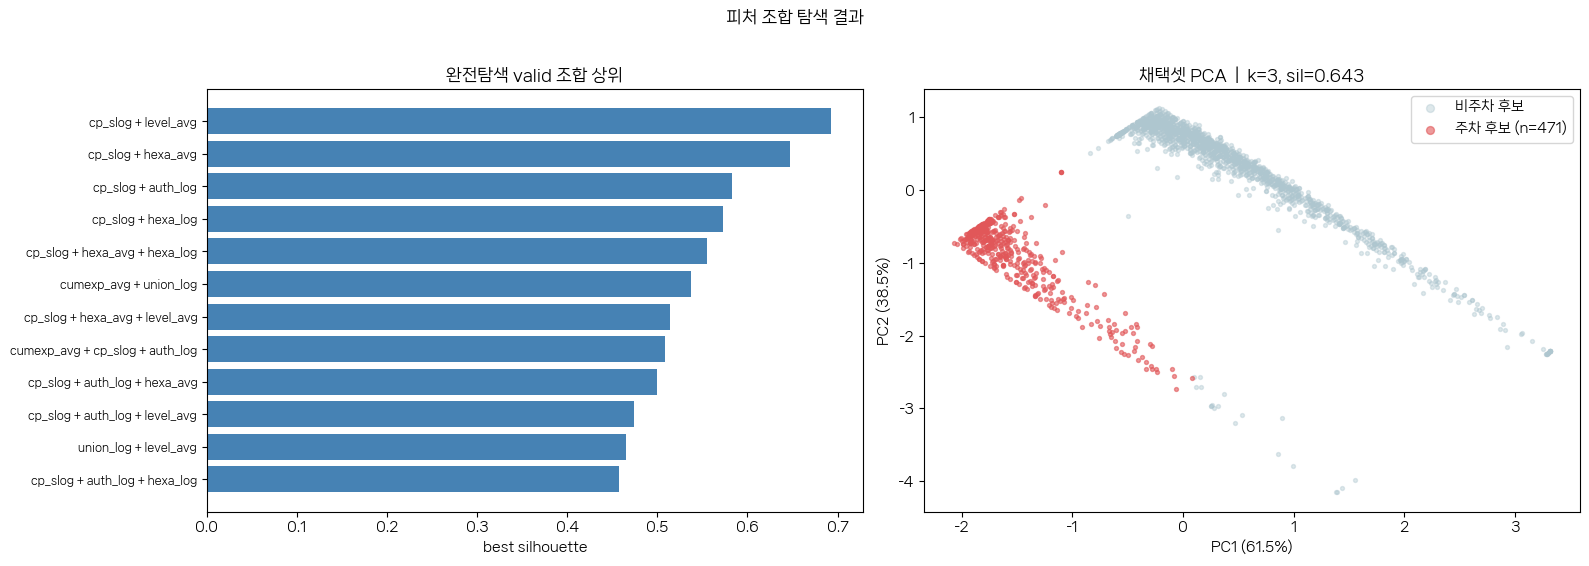

In [8]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 5.5))
topN = (exh_valid.head(12).iloc[::-1] if len(exh_valid) else exh.sort_values("sil").tail(12))
axL.barh(range(len(topN)), topN["sil"], color="steelblue")
axL.set_yticks(range(len(topN))); axL.set_yticklabels([" + ".join(f) for f in topN["features"]], fontsize=8)
axL.set_xlabel("best silhouette"); axL.set_title("완전탐색 valid 조합 상위")
ispk = (df_final.loc[idx_opt, "fs_cluster"] == stagnant_id).values
pca = PCA(n_components=2, random_state=RANDOM_STATE); P = pca.fit_transform(Xo)
axR.scatter(P[~ispk, 0], P[~ispk, 1], s=8, alpha=0.4, color="#aec6cf", label="비주차 후보")
axR.scatter(P[ispk, 0], P[ispk, 1], s=8, alpha=0.6, color="#e15759", label=f"주차 후보 (n={int(ispk.sum())})")
ev = pca.explained_variance_ratio_
axR.set_xlabel(f"PC1 ({ev[0]:.1%})"); axR.set_ylabel(f"PC2 ({ev[1]:.1%})")
axR.set_title(f"채택셋 PCA  |  k={FINAL_K}, sil={max(sils):.3f}"); axR.legend(markerscale=2)
plt.suptitle("피처 조합 탐색 결과", y=1.02); plt.tight_layout()
plt.savefig("figures/13_feature_search.png", dpi=150, bbox_inches="tight"); plt.show()

In [9]:
print("=" * 64); print("  피처 선택 실험 요약 (재설계 2026-06)"); print("=" * 64)
print("  접속 통제: 표본 전원 access_active_months>=10 → access family 클러스터링 제외")
print(f"  cumEXP: 통제 후 균일(median {df_final['log1p_avg_monthly_delta_cumexp'].median():.1f}) → 판별력 낮음")
print(f"  채택 피처셋: {OPT_FEATURES}  (source={OPT_SRC}, n_feat={len(OPT_FEATURES)})")
print(f"    -> k={FINAL_K} silhouette={max(sils):.4f} 주차 후보 {n_stag}명 ({n_stag/len(df_final):.1%})")
print("  판별축: 재투자(union/hfrag) 낮음 = 보스재화 미재투자 = 주차 후보 (0.1 정의 정합)")

  피처 선택 실험 요약 (재설계 2026-06)
  접속 통제: 표본 전원 access_active_months>=10 → access family 클러스터링 제외
  cumEXP: 통제 후 균일(median 30.0) → 판별력 낮음
  채택 피처셋: ['cp_slog', 'hexa_avg']  (source=family-diverse (user-pinned), n_feat=2)
    -> k=3 silhouette=0.6431 주차 후보 471명 (23.6%)
  판별축: 재투자(union/hfrag) 낮음 = 보스재화 미재투자 = 주차 후보 (0.1 정의 정합)
